# Optimization

- Stronger cooling lowers classroom temperature but uses more energy. Excessive cooling can make the room too cold.
- An objective function assigns a numerical score to each choice.
- Optimization searches for the best choice while satisfying the constraints.


<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/04-1_Optimization/assets/01_classroom_problem.png" alt="Classroom cooling: balancing comfort and energy use" width="512" style="max-width:100%;height:auto;">


## System boundary

- A system boundary defines what a model includes.
- This model predicts the temperature of one classroom from outdoor temperature, occupancy, and cooling levels.
- Door and window opening are outside the model.


<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/04-1_Optimization/assets/01_classroom_elements.png" alt="Classroom system boundary, inputs, decisions, and outputs" width="512" style="max-width:100%;height:auto;">


## Temperature dynamics

- In this example, warm outdoor air and occupants add heat, while cooling removes heat.

> Next temperature = current temperature + heat gain − cooling effect

- The decision variables are the early and late cooling levels.
- The state variable is indoor temperature. Outdoor temperature and occupancy are fixed across candidates.
- Early cooling changes the starting temperature of the late period, so both decisions must be considered together.


<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/04-1_Optimization/assets/01_classroom_model.png" alt="Classroom temperature dynamics and cooling model" width="512" style="max-width:100%;height:auto;">


## Cooling levels and temperature

- Low cooling does not cool the room enough.
- Moderate cooling brings the room closer to the comfort range.
- Excessive cooling makes the room too cold in the late period.
- Cooling is evaluated over the full temperature trajectory, not just the final temperature.


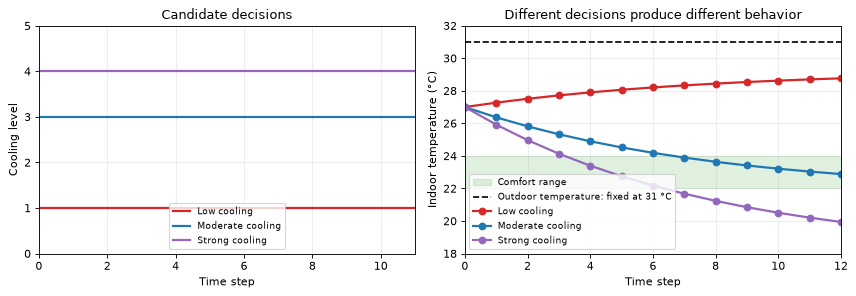

In [1]:
import os
import sys
import numpy as np
import matplotlib

# JSPCV uses its own Matplotlib event bridge. Local notebooks use ipympl.
if sys.platform != "emscripten" and os.environ.get("OPTIMIZATION_STATIC") != "1":
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        try:
            shell.run_line_magic("matplotlib", "widget")
        except (ImportError, RuntimeError, ValueError) as exc:
            raise RuntimeError(
                "Install requirements.txt (including ipympl), restart the kernel, and Run All."
            ) from exc

import matplotlib.pyplot as plt

# Match the compact display scale used by the other optimization figures.
plt.rcParams.update({"figure.dpi": 80, "savefig.dpi": 80})
from types import SimpleNamespace


def _pyplot(*, interactive=False):
    return plt


# Canonical classroom system used throughout Lectures 01-1, 01-2, and 02-1.
TIME_STEPS = 12
INITIAL_TEMPERATURE = 27.0

# Fixed parameters
WEATHER_EXCHANGE = 0.12
OCCUPANT_HEAT = 0.012
COOLING_EFFECT = 0.45

# External inputs
OUTSIDE_TEMPERATURE = np.full(TIME_STEPS, 31.0)
OCCUPANTS = np.full(TIME_STEPS, 20.0)

# Requirement limits
MIN_COOLING = 0.0
MAX_COOLING = 5.0
MIN_TEMPERATURE = 20.0
MAX_TEMPERATURE = 30.0
MAX_ENERGY = 60.0


def expand_decision(decision):
    """Expand (early cooling, late cooling) into the 12-step decision schedule."""
    early_cooling, late_cooling = map(float, decision)
    return np.r_[
        np.full(6, early_cooling),
        np.full(6, late_cooling),
    ]


def simulate_classroom(decision):
    """Apply the 01-1 state equation and return the complete state path."""
    cooling_schedule = expand_decision(decision)
    temperatures = [INITIAL_TEMPERATURE]

    for outdoor, people, cooling in zip(
        OUTSIDE_TEMPERATURE, OCCUPANTS, cooling_schedule
    ):
        current = temperatures[-1]
        next_temperature = (
            current
            + WEATHER_EXCHANGE * (outdoor - current)
            + OCCUPANT_HEAT * people
            - COOLING_EFFECT * cooling
        )
        temperatures.append(next_temperature)

    return cooling_schedule, np.asarray(temperatures)


def performance_outputs(cooling_schedule, temperatures):
    """Calculate the raw performance outputs D and E defined in 01-1."""
    discomfort = np.sum(
        np.maximum(temperatures[1:] - 24.0, 0.0) ** 2
        + np.maximum(22.0 - temperatures[1:], 0.0) ** 2
    )
    energy = 0.5 * np.sum(cooling_schedule ** 2)
    return float(discomfort), float(energy)


def evaluate_candidate(decision, energy_weight=1.0):
    """Simulate one decision, check requirements, and calculate its score."""
    decision = tuple(map(float, decision))
    cooling_schedule, temperatures = simulate_classroom(decision)
    discomfort, energy = performance_outputs(cooling_schedule, temperatures)

    violations = []
    if not all(MIN_COOLING <= value <= MAX_COOLING for value in decision):
        violations.append("cooling bound")
    if temperatures[1:].min() < MIN_TEMPERATURE:
        violations.append("minimum temperature")
    if temperatures[1:].max() > MAX_TEMPERATURE:
        violations.append("maximum temperature")
    if energy > MAX_ENERGY:
        violations.append("energy limit")

    return {
        "decision": decision,
        "cooling_schedule": cooling_schedule,
        "temperatures": temperatures,
        "discomfort": discomfort,
        "energy": energy,
        "energy_weight": float(energy_weight),
        "objective": discomfort + float(energy_weight) * energy,
        "feasible": not violations,
        "violations": tuple(violations),
    }


def enumerate_grid_candidates(energy_weight=1.0, step=0.5):
    """Evaluate the transparent decision grid used in Lectures 01-1 and 01-2."""
    levels = np.arange(MIN_COOLING, MAX_COOLING + step / 2, step)
    return [
        evaluate_candidate((early, late), energy_weight)
        for early in levels
        for late in levels
    ]


def best_grid_candidate(energy_weight=1.0, step=0.5):
    """Return the lowest-scoring feasible candidate on the stated grid."""
    candidates = enumerate_grid_candidates(energy_weight, step)
    return min(
        (candidate for candidate in candidates if candidate["feasible"]),
        key=lambda candidate: candidate["objective"],
    )


def show_system_behavior(evaluate_candidate, *, time_steps=12):
    """Plot a controlled comparison of three constant cooling decisions."""
    plt = _pyplot()
    decisions = ((1.0, 1.0), (3.0, 3.0), (4.0, 4.0))
    labels = ("Low cooling", "Moderate cooling", "Strong cooling")
    colors = ("tab:red", "tab:blue", "tab:purple")
    results = [evaluate_candidate(decision) for decision in decisions]

    decision_steps = np.arange(time_steps)
    state_steps = np.arange(time_steps + 1)
    figure, axes = plt.subplots(1, 2, figsize=(10.8, 3.8))

    for label, color, result in zip(labels, colors, results):
        axes[0].step(
            decision_steps,
            result["cooling_schedule"],
            where="mid",
            linewidth=2,
            color=color,
            label=label,
        )
    axes[0].set(
        xlabel="Time step",
        ylabel="Cooling level",
        title="Candidate decisions",
        xlim=(0, time_steps - 1),
        ylim=(0, 5),
    )
    axes[0].legend(fontsize=8)

    axes[1].axhspan(22, 24, color="tab:green", alpha=0.15, label="Comfort range")
    axes[1].plot(
        state_steps,
        np.full_like(state_steps, 31.0, dtype=float),
        linestyle="--",
        color="black",
        linewidth=1.5,
        label="Outdoor temperature: fixed at 31 °C",
    )
    for label, color, result in zip(labels, colors, results):
        axes[1].plot(
            state_steps,
            result["temperatures"],
            marker="o",
            linewidth=2,
            color=color,
            label=label,
        )
    axes[1].set(
        xlabel="Time step",
        ylabel="Indoor temperature (°C)",
        title="Different decisions produce different behavior",
        xlim=(0, time_steps),
        ylim=(18, 32),
    )
    axes[1].legend(fontsize=8)

    for axis in axes:
        axis.grid(alpha=0.25)
    figure.tight_layout()
    plt.show()
    plt.close(figure)
    return figure

system_behavior_figure = show_system_behavior(
    evaluate_candidate, time_steps=TIME_STEPS
)


## Performance measures

- Discomfort increases when temperature deviates farther from the 22–24 °C comfort range or remains uncomfortable longer.
- Energy use increases with cooling intensity and duration.
- Both insufficient and excessive cooling can produce poor performance.


<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/04-1_Optimization/assets/01_classroom_performance.png" alt="Discomfort and energy performance measures" width="512" style="max-width:100%;height:auto;">


## Constraints and objective

- Constraints specify required limits on cooling levels, indoor temperature, and energy use.
- A temperature of 25 °C causes discomfort but is allowed. Candidates that exceed 30 °C are infeasible.
- Feasible candidates are compared using the following cost. Lower cost is better.

> Cost = discomfort + energy weight × energy use

- A larger energy weight penalizes energy-intensive candidates more strongly.
- Changing the weight can change candidate rankings without changing their temperature trajectories.


<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/04-1_Optimization/assets/01_classroom_optimization.png" alt="Cooling constraints and optimization objective" width="640" style="max-width:100%;height:auto;">


## Decisions and outcomes

> Cooling decision → temperature simulation → discomfort and energy evaluation

- Decision space contains the combinations of decision variables. The plot uses late cooling on the horizontal axis and early cooling on the vertical axis.
- Performance space contains the resulting performance measures: energy use and discomfort.
- Grid search evaluates predefined candidates. This example selects the feasible candidate with the lowest cost among 121 combinations.
- The orange square marks the current choice; the gold star marks the best grid candidate. Better solutions may lie between grid points.
- Evaluating every candidate becomes expensive as the search grows. GD, GA, and PSO use different rules to choose new candidates.


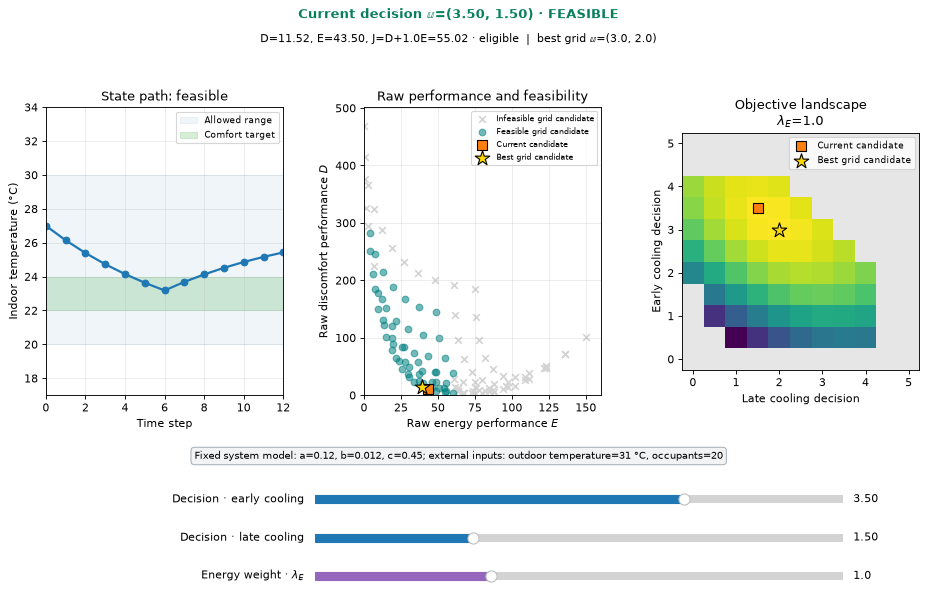

In [2]:
def show_classroom_explorer(
    evaluate_candidate,
    enumerate_candidates,
    *,
    time_steps=12,
    min_cooling=0.0,
    max_cooling=5.0,
    min_temperature=20.0,
    max_temperature=30.0,
    initial_decision=(3.0, 2.0),
):
    """Build the shared decision/state/performance interactive explorer."""
    plt = _pyplot(interactive=True)
    from matplotlib.widgets import Slider

    plt.close("all")
    step = 0.5
    baseline = enumerate_candidates(energy_weight=1.0, step=step)
    levels = np.arange(min_cooling, max_cooling + step / 2, step)
    feasible_points = np.array([
        (record["energy"], record["discomfort"])
        for record in baseline if record["feasible"]
    ])
    infeasible_points = np.array([
        (record["energy"], record["discomfort"])
        for record in baseline if not record["feasible"]
    ])

    def objective_landscape(energy_weight):
        values = np.full((len(levels), len(levels)), np.nan)
        records = enumerate_candidates(energy_weight, step=step)
        for record in records:
            early, late = record["decision"]
            if record["feasible"]:
                values[
                    int(round((early - min_cooling) / step)),
                    int(round((late - min_cooling) / step)),
                ] = record["objective"]
        best = min(
            (record for record in records if record["feasible"]),
            key=lambda record: record["objective"],
        )
        return values, best

    initial_weight = 1.0
    current = evaluate_candidate(initial_decision, initial_weight)
    initial_landscape, best = objective_landscape(initial_weight)
    figure, axes = plt.subplots(1, 3, figsize=(12, 8))
    figure.subplots_adjust(left=0.07, right=0.98, bottom=0.35, top=0.80, wspace=0.34)

    axes[0].axhspan(
        min_temperature,
        max_temperature,
        color="tab:blue",
        alpha=0.07,
        label="Allowed range",
    )
    axes[0].axhspan(22, 24, color="tab:green", alpha=0.18, label="Comfort target")
    temperature_line, = axes[0].plot(
        np.arange(time_steps + 1),
        current["temperatures"],
        marker="o",
        linewidth=2,
        color="tab:blue",
    )
    axes[0].set(
        xlabel="Time step",
        ylabel="Indoor temperature (°C)",
        xlim=(0, time_steps),
        ylim=(17, 34),
    )
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].scatter(
        infeasible_points[:, 0],
        infeasible_points[:, 1],
        marker="x",
        color="lightgray",
        label="Infeasible grid candidate",
    )
    axes[1].scatter(
        feasible_points[:, 0],
        feasible_points[:, 1],
        color="teal",
        alpha=0.55,
        label="Feasible grid candidate",
    )
    current_performance = axes[1].scatter(
        current["energy"], current["discomfort"],
        marker="s", s=90, color="tab:orange", edgecolor="black",
        label="Current candidate",
    )
    best_performance = axes[1].scatter(
        best["energy"], best["discomfort"],
        marker="*", s=190, color="gold", edgecolor="black",
        label="Best grid candidate",
    )
    all_points = feasible_points.tolist() + infeasible_points.tolist()
    axes[1].set(
        xlabel="Raw energy performance $E$",
        ylabel="Raw discomfort performance $D$",
        xlim=(0, max(point[0] for point in all_points) * 1.07),
        ylim=(0, max(point[1] for point in all_points) * 1.07),
        title="Raw performance and feasibility",
    )
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=7)

    color_map = plt.colormaps["viridis_r"].copy()
    color_map.set_bad("#e6e6e6")
    objective_image = axes[2].imshow(
        initial_landscape,
        origin="lower",
        cmap=color_map,
        extent=(min_cooling - 0.25, max_cooling + 0.25) * 2,
        aspect="equal",
    )
    current_decision = axes[2].scatter(
        initial_decision[1], initial_decision[0],
        marker="s", s=90, color="tab:orange", edgecolor="black",
        label="Current candidate",
    )
    best_decision = axes[2].scatter(
        best["decision"][1], best["decision"][0],
        marker="*", s=190, color="gold", edgecolor="black",
        label="Best grid candidate",
    )
    axes[2].set(
        xticks=np.arange(min_cooling, max_cooling + 0.1, 1),
        yticks=np.arange(min_cooling, max_cooling + 0.1, 1),
        xlabel="Late cooling decision",
        ylabel="Early cooling decision",
    )
    axes[2].legend(fontsize=8)

    status_text = figure.text(
        0.5, 0.955, "", ha="center", va="top", fontsize=12, fontweight="bold"
    )
    metrics_text = figure.text(0.5, 0.915, "", ha="center", va="top", fontsize=10)
    figure.text(
        0.5,
        0.255,
        "Fixed system model: a=0.12, b=0.012, c=0.45; "
        "external inputs: outdoor temperature=31 °C, occupants=20",
        ha="center",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#f1f3f5", edgecolor="#adb5bd"),
    )

    early_axis = figure.add_axes([0.35, 0.175, 0.55, 0.025])
    late_axis = figure.add_axes([0.35, 0.115, 0.55, 0.025])
    weight_axis = figure.add_axes([0.35, 0.055, 0.55, 0.025])
    early_slider = Slider(
        early_axis,
        "Decision · early cooling",
        min_cooling,
        max_cooling,
        valinit=initial_decision[0],
        valstep=0.25,
        valfmt="%1.2f",
        color="tab:blue",
    )
    late_slider = Slider(
        late_axis,
        "Decision · late cooling",
        min_cooling,
        max_cooling,
        valinit=initial_decision[1],
        valstep=0.25,
        valfmt="%1.2f",
        color="tab:blue",
    )
    weight_slider = Slider(
        weight_axis,
        "Energy weight · $\\lambda_E$",
        0.0,
        3.0,
        valinit=initial_weight,
        valstep=0.1,
        valfmt="%1.1f",
        color="tab:purple",
    )
    state = {}

    def refresh(_=None):
        decision = (early_slider.val, late_slider.val)
        energy_weight = weight_slider.val
        current = evaluate_candidate(decision, energy_weight)
        landscape, best = objective_landscape(energy_weight)
        status = "FEASIBLE" if current["feasible"] else "INFEASIBLE"
        temperature_line.set_ydata(current["temperatures"])
        current_performance.set_offsets([[current["energy"], current["discomfort"]]])
        best_performance.set_offsets([[best["energy"], best["discomfort"]]])
        objective_image.set_data(landscape)
        objective_image.set_clim(np.nanmin(landscape), np.nanmax(landscape))
        current_decision.set_offsets([[decision[1], decision[0]]])
        best_decision.set_offsets([[best["decision"][1], best["decision"][0]]])
        axes[0].set_title(f"State path: {status.lower()}")
        axes[2].set_title(f"Objective landscape\n$\\lambda_E$={energy_weight:.1f}")
        status_text.set_text(
            f"Current decision $\\mathbb{{u}}$=({decision[0]:.2f}, {decision[1]:.2f}) · {status}"
        )
        status_text.set_color("#087f5b" if current["feasible"] else "#c92a2a")
        eligibility = "eligible" if current["feasible"] else "rejected before comparison"
        metrics_text.set_text(
            f"D={current['discomfort']:.2f}, E={current['energy']:.2f}, "
            f"J=D+{energy_weight:.1f}E={current['objective']:.2f} · {eligibility}  |  "
            f"best grid $\\mathbb{{u}}$=({best['decision'][0]:.1f}, {best['decision'][1]:.1f})"
        )
        state.clear()
        state.update(current=current, best=best, energy_weight=energy_weight)
        figure.canvas.draw_idle()

    for slider in (early_slider, late_slider, weight_slider):
        slider.on_changed(refresh)
    figure._classroom_sliders = (early_slider, late_slider, weight_slider)
    refresh()
    plt.show()
    return SimpleNamespace(
        figure=figure,
        state=state,
        refresh=refresh,
        early_slider=early_slider,
        late_slider=late_slider,
        energy_weight_slider=weight_slider,
    )

explorer = show_classroom_explorer(
    evaluate_candidate,
    enumerate_grid_candidates,
    time_steps=TIME_STEPS,
    min_cooling=MIN_COOLING,
    max_cooling=MAX_COOLING,
    min_temperature=MIN_TEMPERATURE,
    max_temperature=MAX_TEMPERATURE,
    initial_decision=(3.5, 1.5),
)
systems_thinking_state = explorer.state